# Running the PULP-DroNet v3 CNN on the GAP9 SoC (in GVSoC Simulation)

## Imports

In [1]:
DIRECTORY_GENERATED_CODE = "./generated_code"

In [2]:
import sys, os
print("Python:", sys.executable)
print("CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV"))
print("AT_HOME:", os.environ.get("AT_HOME"))
print("PYTHONPATH:", os.environ.get("PYTHONPATH"))

Python: /home/lamberti/anaconda3/envs/gap_sdk_5.20.4/bin/python
CONDA_DEFAULT_ENV: gap_sdk_5.20.4
AT_HOME: /home/lamberti/gap/5.20.4/gap_sdk_private/tools/autotiler_v3
PYTHONPATH: /home/lamberti/gap/5.20.4/gap_sdk_private/utils/gapy_v2/bin:/home/lamberti/gap/5.20.4/gap_sdk_private/tools/audio-framework/python_tools:/home/lamberti/gap/5.20.4/gap_sdk_private/gvsoc/gvsoc/models/:/home/lamberti/gap/5.20.4/gap_sdk_private/gvsoc/gvsoc_gap:/home/lamberti/gap/5.20.4/gap_sdk_private/install/workstation/python:/home/lamberti/gap/5.20.4/gap_sdk_private/utils/:/home/lamberti/gap/5.20.4/gap_sdk_private/tools/nntool:


In [3]:
# NNTool Imports
import sys
sys.path.append("/home/lamberti/gap/5.20.4/gap_sdk_private/tools/nntool/")  # where nntool lives

from nntool.api import NNGraph
from nntool.api.utils import quantization_options, model_settings
from tqdm import tqdm
from glob import glob
from PIL import Image
import numpy as np

In [4]:
# IMAV Imports
import os
import sys
import numpy as np

from matplotlib import pyplot as plt
# %matplotlib inline      # must be done before matplotlib import
# %matplotlib notebook  # must be done before matplotlib import

# images
import cv2
import imgaug.augmenters as iaa
#Pillow
from PIL import Image as Image
from IPython.display import display as display
# WAND
# from wand.image import Image as WImage
# from wand.display import display as Wdisplay

In [5]:
# Dronet Imports
sys.path.append('./') # needed for models and utility
# from cnn import dronet_imav, ResBlock, dronet
import cnn
# from augmentation import ImgAugTransform, Brightness


In [6]:
# Other Imports
import torch
import torch.nn as nn
from torchvision import datasets
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchinfo import summary
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

import importlib

2026-05-22 10:26:16.638018: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-22 10:26:16.648514: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779438376.664136 1433681 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779438376.668168 1433681 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-22 10:26:16.684657: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## DroNet v3 CNN

### Arguments

In [7]:
args = {
    'model_weights_dronet': 'pre-trained/pulp-dronet-v3-resblock-1.0.pth',
    'model_weights_dronet_onnx': 'pre-trained/pulp-dronet-v3-resblock-1.0.onnx',
    'data_path_HM0360': './dataset/HM0360/',
    'data_path_HM01B0': './dataset/HM01B0/',
}

AUGMENTATION = False
MORE_BRIGHTNESS = False

# Bayer demosaicing: set True when images come from a raw Bayer-pattern sensor
# (e.g. Himax HM0360 in RAW8 mode).
# pattern: 'BG'=BGGR  'RG'=RGGB  'GB'=GBRG  'GR'=GRBG
DEBAYER = True
DEBAYER_PATTERN = 'BG'  # BGGR — standard for Himax HM0360

### Data

##### Augmentation

In [8]:
class DebayerTransform:
    """Demosaic a raw Bayer-pattern grayscale image to a proper grayscale image.
    Uses OpenCV bilinear interpolation; preserves full resolution.
    pattern: 'BG'=BGGR, 'RG'=RGGB, 'GB'=GBRG, 'GR'=GRBG
    """
    _codes = {
        'BG': cv2.COLOR_BayerBG2GRAY,
        'GB': cv2.COLOR_BayerGB2GRAY,
        'RG': cv2.COLOR_BayerRG2GRAY,
        'GR': cv2.COLOR_BayerGR2GRAY,
    }
    def __init__(self, pattern='BG'):
        self.code = self._codes[pattern]
    def __call__(self, pil_img):
        arr = np.array(pil_img.convert("L"))  # force single-channel; ImageFolder loads as RGB
        gray = cv2.cvtColor(arr, self.code)
        return Image.fromarray(gray)


import torchvision.transforms.functional as TF
crop_size = 200
cx, cy = 100, 120  # custom center: x, y

def crop_around_center(img):
    left = int(cx - crop_size / 2)
    top = int(cy - crop_size / 2)
    return TF.crop(img, top=top, left=left, height=crop_size, width=crop_size)


class Brightness:
    def __init__(self, brightness_factor=1.):
        self.brightness_factor = brightness_factor
    def __call__(self, image):
        image = transforms.functional.adjust_brightness(image, self.brightness_factor)
        # image.save('debug.png')
        return image

        
def get_transformations(crop=False, crop_custom=False, debayer=False, brightness=False, debayer_pattern='BG'):
    transf_list = []
    print("Transformations:")

    if debayer:
        print(f"\t- DEBAYER ACTIVE (Bayer {debayer_pattern} -> grayscale)")
        transf_list += [DebayerTransform(pattern=debayer_pattern)]

    if AUGMENTATION == True:
        transf_list += [ImgAugTransform()]

    if brightness:
        print("\t- MORE BRIGHTNESS ACTIVE")
        transf_list += [Brightness(brightness_factor=0.5)]

    if crop:
        print("\t- CROPPING ACTIVE")
        transf_list += [transforms.CenterCrop(200)]
    elif crop_custom:
        print("\t- CROPPING custom ACTIVE")
        transf_list += [transforms.Lambda(crop_around_center)]
    else:
        size = (200, 200)
        print("\t- RESIZE TO:", size)
        transf_list += [transforms.Resize(size)]

    transf_list += [
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor()
    ]
    transformations = transforms.Compose(transf_list)
    return transformations


##### Images / Datasets

In [9]:
class ImageFolderWithPaths(datasets.ImageFolder):
    """Custom dataset that includes image file paths. Extends
    torchvision.datasets.ImageFolder
    """
    # override the __getitem__ method. this is the method that dataloader calls
    def __getitem__(self, index):
        # this is what ImageFolder normally returns
        original_tuple = super(ImageFolderWithPaths, self).__getitem__(index)
        # the image file path
        path = self.imgs[index][0]
        # make a new tuple that includes original and the path
        tuple_with_path = (original_tuple + (path,))
        return tuple_with_path

In [10]:
class CustomGAPDataLoader():
    """
    Based on MyDataLoader example from NNTool API reference on collecting
    statistics for quantization.
    """

    def __init__(self, image_files, max_idx=None, transpose_to_chw=False, transpose_to_hwc=False):
        self._file_list = image_files
        self._idx = 0
        self._max_idx = max_idx if max_idx is not None else len(image_files)
        self._transpose_to_chw = transpose_to_chw
        self._transpose_to_hwc = transpose_to_hwc

    def __iter__(self):
        self._idx = 0
        return self

    def __next__(self):
        if self._idx >= self._max_idx:
            raise StopIteration()
        tuple_with_path = self._file_list[self._idx]

        # Image needs to be a np.array. As a torch.tensor it won't work with NNTools
        # quantization tool
        img_array = np.array(tuple_with_path[0])

        # Transpose to CHW or HWC
        if self._transpose_to_chw:
            img_array = img_array.transpose(2, 0, 1)

        elif self._transpose_to_hwc:
            img_array = img_array.transpose(1, 2, 0)

        self._idx += 1
        return img_array

In [11]:
transformations_imav = get_transformations(crop_custom=True, brightness=False, debayer=DEBAYER, debayer_pattern=DEBAYER_PATTERN)
dataset_HM0360 = ImageFolderWithPaths(args['data_path_HM0360'], transformations_imav)
dataloader_HM0360 = CustomGAPDataLoader(dataset_HM0360)

transformations_imav = get_transformations(crop=False)
dataset_HM01B0 = ImageFolderWithPaths(args['data_path_HM01B0'], transformations_imav)
dataloader_HM01B0 = CustomGAPDataLoader(dataset_HM01B0)

dataset = dataset_HM0360
dataloader = dataloader_HM0360

Transformations:
	- DEBAYER ACTIVE (Bayer BG -> grayscale)
	- CROPPING custom ACTIVE
Transformations:
	- RESIZE TO: (200, 200)


### Pretrained IMAV Model

In [12]:
def load_weights(net, model_weights, device='cuda:0', verbose=False):
    # load previous weights
    if os.path.isfile(model_weights):
        if torch.cuda.is_available():
            checkpoint = torch.load(model_weights, map_location=device)
            print('loaded checkpoint on cuda')
        else:
            checkpoint = torch.load(model_weights, map_location='cpu')
            print('CUDA not available: loaded checkpoint on cpu')
        if 'state_dict' in checkpoint:
            checkpoint = checkpoint['state_dict']
        else:
            print('Warning: failed to find the [''state_dict''] inside the checkpoint. you probably are not providing a full checkpoint. I will try to open it anyways.')
        net.load_state_dict(checkpoint)
        print('Loaded state_dict inside network. Enjoy!')

    else:
        raise RuntimeError('Failed to open checkpoint. provide a checkpoint.pth.tar file')
    net.to(device)
    if verbose: summary(net, input_size=(1, 1, 324, 324))
    return net

In [13]:
# Verify input image size
image_size = list(np.squeeze(next(iter(dataset))[0]).shape)
print(f"Input image size: {image_size} pixels")
# dronet-v3 expects 200x200: conv5x5/2 -> 100x100 -> pool/2 -> 50x50
#   -> Block1/2 -> 25x25 -> Block2/2 -> 13x13 -> Block3/2 -> 7x7
# FC input: 128 * 7 * 7 = 6272 features

Input image size: [200, 200] pixels


In [14]:
importlib.reload(cnn)  # reload in case cnn.py was modified

net_dronet = cnn.dronet(depth_mult=1., block_class=cnn.ResBlock)
net_dronet = load_weights(net_dronet, args['model_weights_dronet'], device=device, verbose=False)
net_dronet.eval()

CUDA not available: loaded checkpoint on cpu
Loaded state_dict inside network. Enjoy!


dronet(
  (first_conv): Conv2d(1, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU6()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Block1): ResBlock(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU6()
    (relu2): ReLU6()
    (bypass): Conv2d(32, 32, kernel_size=(1, 1), stride=(2, 2), bias=False)
    (bn_bypass): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu3): ReLU6()
  )
  (Block2): ResBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2,

## NNTool

### Importing the ONNX Model

If onnx version of the model is not yet generated, you can generate it from pytorch version

In [15]:
def export_to_onnx(dataloader):
    dummy_input = next(iter(dataloader))
    print(f'Original image shape: {dummy_input.shape}')
    dummy_input = torch.unsqueeze(torch.tensor(dummy_input), dim=0)
    print(f'Unsqueezed image shape: {dummy_input.shape}')
    net_dronet.eval()
    torch.onnx.export(net_dronet, dummy_input, args['model_weights_dronet_onnx'])
    print(f"ONNX model exported to: {args['model_weights_dronet_onnx']}")

export_to_onnx(dataloader)

Original image shape: (1, 200, 200)
Unsqueezed image shape: torch.Size([1, 1, 200, 200])


ONNX model exported to: pre-trained/pulp-dronet-v3-resblock-1.0.onnx


In [16]:
G = NNGraph.load_graph(args['model_weights_dronet_onnx'])

G.adjust_order()
G.fusions("scaled_match_group")

get_output_size: _first_conv_Conv has a padding setting not to SAME but in reality it is, changing the original padding from (2, 2)x(2, 2) to (2, 1)x(2, 1)
get_output_size: _Block1_conv1_Conv has a padding setting not to SAME but in reality it is, changing the original padding from (1, 1)x(1, 1) to (1, 0)x(1, 0)


In [17]:
print(G.show())

+------+-------------------+------------------+-------------+-------------+--------+--------+--------+---------+------------------+------------------+
| Step |     Step name     |    Operation     | Input Dims  | Output Dims | Inputs | Active | Params |   Ops   |      Params      |      Hints       |
|      |                   |                  |  (0x1x2x3)  |  (0x1x2x3)  |        |  size  |  size  |         |                  |                  |
+======+===================+==================+=============+=============+========+========+========+=========+==================+==================+
|  0   | input_1           | input            | 1x1x200x200 | 1x1x200x200 |        | 40000  |   0    |         | I 1x1x200x200    | in: none out:    |
|      |                   |                  |             |             |        |        |        |         |                  | none             |
+------+-------------------+------------------+-------------+-------------+--------+--------+-

### Quantization

In [18]:
# from nntool.api.utils import RandomIter
# stats_fake = G.collect_statistics(RandomIter.fake(G))

In [19]:
dummy_input = next(iter(dataloader))
print(f'Calibration image shape: {dummy_input.shape}')
print(f'min: {np.min(dummy_input):.4f}, max: {np.max(dummy_input):.4f}')

Calibration image shape: (1, 200, 200)
min: 0.1451, max: 1.0000


In [20]:
stats = G.collect_statistics(dataloader_HM01B0, progress=True)

0it [00:00, ?it/s]

1it [00:00,  3.36it/s]

2it [00:00,  2.85it/s]

3it [00:01,  2.68it/s]

4it [00:01,  2.70it/s]

...

19it [00:05,  3.36it/s]

20it [00:06,  3.54it/s]

21it [00:06,  3.66it/s]

22it [00:06,  3.19it/s]

22it [00:06,  3.22it/s]

In [21]:
G.quantize(
    statistics=stats,
    # When using the NE16 neural engine, HWC is used inside that engine.
    # NNTool automatically transforms the layers in the graph to HWC if necessary
    # in this quantization step.
    # Therefore it makes sense to activate the HWC kernels as well (`hwc=True`).
    graph_options=quantization_options(
        weight_bits=8,
        use_ne16=True,
        hwc=True
    ),
)

In [22]:
# G.draw()
# print(G.show())

In [23]:
def print_quantization_ranges(G):
    from nntool.graph.types import InputNode, OutputNode
    print(f"{'Node':>6}  {'Name':<30}  {'dtype':>6}  {'zp':>4}  {'scale':>10}  "
          f"{'int_min→float':>18}  {'int 0→float':>14}  {'int_max→float':>18}")
    print("-" * 105)
    for i, node in enumerate(G.nodes()):
        if not isinstance(node, (InputNode, OutputNode)):
            continue
        qrec = G.quantization.get(node.name)
        if not qrec:
            continue
        qs = qrec.out_qs or qrec.in_qs
        for q in (qs or []):
            signed  = q.signed
            zp      = int(q.zero_point.flat[0])
            sc      = float(q.scale.flat[0])
            imin    = -128 if signed else 0
            imax    =  127 if signed else 255
            dtype   = 'int8' if signed else 'uint8'
            print(f"[{i:3}]  {node.name:<30}  {dtype:>6}  {zp:>4}  {sc:>10.6f}  "
                  f"  int {imin:4d} → {(imin-zp)*sc:+.4f}  "
                  f"  int   0 → {(0-zp)*sc:+.4f}  "
                  f"  int {imax:3d} → {(imax-zp)*sc:+.4f}")

print_quantization_ranges(G)


  Node  Name                             dtype    zp       scale       int_min→float     int 0→float       int_max→float
---------------------------------------------------------------------------------------------------------
[  0]  input_1                          uint8     0    0.003922    int    0 → +0.0000    int   0 → +0.0000    int 255 → +1.0000
[  1]  output_1                         uint8   128    0.049134    int    0 → -6.2891    int   0 → -6.2891    int 255 → +6.2400
[  2]  output_2                         uint8   128    0.007874    int    0 → -1.0079    int   0 → -1.0079    int 255 → +1.0000


### Test Accurary

In [24]:
def inference_torch(image, net, verbose=False):
    net.eval()
    if verbose: print('size tensor:\t', image.shape)
    image = torch.unsqueeze(image, dim=0)
    if verbose: print('size tensor unsqueezed:\t', image.shape, end="\n\n")
    with torch.no_grad():
        output= net(image)
    return output

In [25]:
def get_output_idxs(G):
    """Return step indices of output nodes (output_1=steer, output_2=coll)."""
    from nntool.graph.types import OutputNode
    return [i for i in range(len(G)) if isinstance(G[i], OutputNode)]

def print_outputs(outputs, model_quantized=False, precision=4):
    """Print dronet-v3 outputs: steer (unbounded) and collision (sigmoid 0-1)."""
    if not model_quantized:
        steer_output = outputs[0].cpu().detach().numpy()
        coll_output  = outputs[1].cpu().detach().numpy()
    else:
        out_idxs = get_output_idxs(G)
        steer_output = outputs[out_idxs[0]][0]
        coll_output  = outputs[out_idxs[1]][0]

    print(f'Steer:     {np.round(steer_output, precision)}', end="\t")
    print(f'Collision: {np.round(coll_output, precision)}')
    return steer_output, coll_output

In [26]:
def view_image(image, save=True, save_path='./', verbose=True):
    if verbose: print('size image:\t', image.shape)
#     if save: cv2.imwrite(save_path, image)

    image_array = image.squeeze().numpy()*255
    if verbose: print('size array:\t', image_array.shape)

    ### OPENCV ###
    if save: cv2.imwrite(save_path, image_array)
    plt.imshow(image_array,cmap='gray')
    plt.show()

    #### PILLOW ####
#     pil_img = Image.fromarray(image_array, 'L')
#     pil_img.show()
#     display(pil_img)     #PILLOW
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Converting BGR to RGB
#     display(Image.fromarray(img))


Output node step indices: [50, 53]  → [steer, collision/sigmoid]



Float output:		Steer=-0.0216  Collision=0.0000


Quant/dequant output:	Steer=0.0000  Collision=0.0000
Int output (raw):	Steer=128  Collision=128
Image range:		min=0.1451  max=1.0000
size image:	 torch.Size([1, 200, 200])
size array:	 (200, 200)


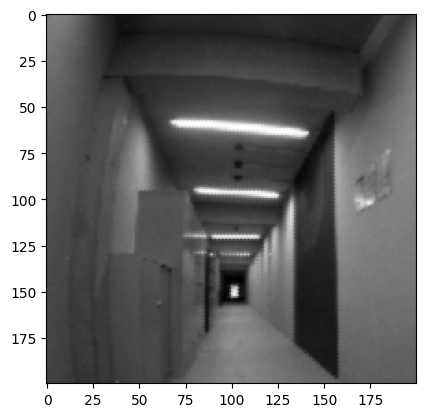

In [27]:
data_iter = iter(dataloader)
img_test = next(data_iter)

out_idxs = get_output_idxs(G)
print(f"Output node step indices: {out_idxs}  → [steer, collision/sigmoid]\n")

float_execution = G.execute([img_test], quantize=False, dequantize=False)
steer_float = float_execution[out_idxs[0]][0]
coll_float  = float_execution[out_idxs[1]][0]
print(f"Float output:\t\tSteer={float(np.squeeze(steer_float)):.4f}  Collision={float(np.squeeze(coll_float)):.4f}")

quant_execution = G.execute([img_test], quantize=True, dequantize=True)
steer_quant = quant_execution[out_idxs[0]][0]
coll_quant  = quant_execution[out_idxs[1]][0]
print(f"Quant/dequant output:\tSteer={float(np.squeeze(steer_quant)):.4f}  Collision={float(np.squeeze(coll_quant)):.4f}")

int_execution = G.execute([img_test], quantize=True, dequantize=False)
steer_int = int_execution[out_idxs[0]][0]
coll_int  = int_execution[out_idxs[1]][0]
print(f"Int output (raw):\tSteer={np.squeeze(steer_int)}  Collision={np.squeeze(coll_int)}")
print(f"Image range:\t\tmin={np.min(img_test):.4f}  max={np.max(img_test):.4f}")

view_image(torch.tensor(img_test), save=False, verbose=True)

In [28]:
from nntool.graph.types import ConstantInputNode
qsnrs_by_layer = G.qsnrs(float_execution, quant_execution)
print("QSNR layer by layer (skipping constant layers like weights and biases):")
print(f"{'Layer Name':>30} (  #): {'QSNR':4}")
for i, q in enumerate(qsnrs_by_layer):
    if isinstance(G[i], ConstantInputNode):
        continue
    print(f"{G[i].name:>30} ({i:3}): {q:4}")

QSNR layer by layer (skipping constant layers like weights and biases):
                    Layer Name (  #): QSNR
                       input_1 (  0):  147
   _first_conv_Conv_reshape_in (  1):  147
       _first_conv_Conv_fusion (  4):   40
     _Block1_conv1_Conv_fusion (  7):   34
     _Block1_conv2_Conv_fusion ( 10):   33
_Block1_conv2_Conv_reshape_out ( 11):   33
    _Block1_bypass_Conv_fusion ( 14):   34
_Block1_bypass_Conv_reshape_out ( 15):   34
                        expr_0 ( 16):   33
 _Block2_conv1_Conv_reshape_in ( 17):   33
     _Block2_conv1_Conv_fusion ( 20):   31
     _Block2_conv2_Conv_fusion ( 23):   30
_Block2_conv2_Conv_reshape_out ( 24):   30
    _Block2_bypass_Conv_fusion ( 27):   27
_Block2_bypass_Conv_reshape_out ( 28):   27
                        expr_1 ( 29):   29
 _Block3_conv1_Conv_reshape_in ( 30):   29
     _Block3_conv1_Conv_fusion ( 33):   28
     _Block3_conv2_Conv_fusion ( 36):   27
_Block3_conv2_Conv_reshape_out ( 37):   27
    _Block3_bypass_Conv

In [29]:
# Uncomment to compare NNTool output vs original PyTorch model
# img_test = next(dataloader)
# print("INPUT")
# outputs_orig = inference_torch(torch.tensor(img_test), net_dronet, verbose=True)
# print("OUTPUT ORIGINAL TORCH MODEL")
# out_orig = print_outputs(outputs_orig, model_quantized=False, precision=4)
# print("OUTPUT QUANTIZED GAP MODEL")
# outputs_quant = G.execute([img_test], quantize=True, dequantize=True)
# out_quant = print_outputs(outputs_quant, model_quantized=True, precision=4)
# view_image(torch.tensor(img_test), save=False, verbose=True)

### Run on target
NNTool allows the user to directly get performance metrics of the platform directly from python APIs by generating a template project and run it.
NOTE: the "gap9_project" was generated by this command, and then changed to adapt in a real application.

In [30]:
# Quantize a single test image to get integer tensors for target execution
out_idxs = get_output_idxs(G)

qout = G.execute(img_test, quantize=True, dequantize=False)

print("Input (quantized uint8):")
int_test = qout[0][0]
print(int_test)
print("Shape:", int_test.shape)

print("\nOutputs (quantized integer):")
print(f"Steer (int8):      {qout[out_idxs[0]][0]}")
print(f"Collision (uint8): {qout[out_idxs[1]][0]}")

Input (quantized uint8):
[[[[126 126 141 ...  91  95 100]
   [133 133 144 ...  93  97 102]
   [143 143 144 ...  95  99 104]
   ...
   [ 94  94  92 ... 117 116 117]
   [ 93  93  92 ... 118 117 117]
   [ 93  93  92 ... 116 116 115]]]]
Shape: (1, 1, 200, 200)

Outputs (quantized integer):
Steer (int8):      [128]
Collision (uint8): [128]


In [31]:
# Autotiler options: make the autotiler allocate the input of the network and reuse that space after the first layer
# more L2 for the rest of the network
# G[0].at_options.allocate = 1
# G[0].at_options

In [32]:
directory = DIRECTORY_GENERATED_CODE
mkdir_cmd = f"mkdir -p {directory}"
os.system(mkdir_cmd)

res = G.execute_on_target(
    directory=directory,
    input_tensors=[int_test],
    cmake=True,
    write_out_to_file=True,
    # platform="board", # to run on the actual board
    platform="gvsoc", # to run on gvsoc simulator
    settings=model_settings(
        l1_size=128000,
        l2_size=1000000,
        tensor_directory='./tensors',
    ),   # most important argument that takes all the settings for AUTOTILE code generation
    at_loglevel=2,
    print_output=True,
)

Script started, output log file is '/tmp/tmpeusj3cc1/log.txt'.


The target board you have sourced is : gap9_evk, GAP9_V2.
Release version: 5.20.4


-- [SDK] Version: 5.20.4
-- [Platform] GVSoC
-- [OS] FreeRTOS (Scheduler v2)
-- [Printf] Semihost
-- [Board] GAP Family : 9
-- [Board] GAP Version : 2
-- [AutoTiler] Setup model: pulp_dronet_v3_resblock_1_0
-- Clock speeds - Cluster 370 FC 370 Peripheral 370
-- [Log] none



--- pulp_dronet_v3_resblock_1_0 options ---

-- [pulp_dronet_v3_resblock_1_0] Include directories : /home/lamberti/work/temp/keanu/dronet_on_gap9/generated_code;/home/lamberti/gap/5.20.4/gap_sdk_private/tools/autotiler_v3/Autotiler;/home/lamberti/gap/5.20.4/gap_sdk_private/tools/autotiler_v3/Emulation;/home/lamberti/gap/5.20.4/gap_sdk_private/libs/gap_lib/include;/home/lamberti/gap/5.20.4/gap_sdk_private/utils/power_meas_utils;/home/lamberti/gap/5.20.4/gap_sdk_private/libs/include;/home/lamberti/gap/5.20.4/gap_sdk_private/tools/autotiler_v3/ISP_Libraries;/home/lamberti/gap/5.20.4/gap_sdk_private/tools/autotiler_v3/ISP_Libraries;/home/lamberti/gap/5.20.4/gap_sdk_private/tools/autotiler_v3/CNN_Libraries;/home/lamberti/gap/5.20.4/gap_sdk_private/tools/autotiler_v3/CNN_Libraries_fp32;/home/lamberti/gap/5.20.4/gap_sdk_private/tools/autotiler_v3/CNN_Libraries_fp16;/home/lamberti/gap/5.20.4/gap_sdk_private/tools/autotiler_v3/CNN_Libraries_fp16/CNN_Libraries_fp16x;/home/lamberti/gap/5.20.4/ga

[  1%] Building C object pmsis/fll_pmu/CMakeFiles/fll_pmu_lib.dir/pmu/maestro_voltage.c.obj
[  1%] Building C object pmsis/fll_pmu/CMakeFiles/fll_pmu_lib.dir/fll/fll.c.obj
[  2%] Building C object pmsis/printf/CMakeFiles/pmsis_printf.dir/printf.c.obj


...

[100%] Built target pulp_dronet_v3_resblock_1_0


[100%] Built target image


[100%] Built target flash




	 *** NNTOOL pulp_dronet_v3_resblock_1_0 Example ***

Entering main controller
FC Frequency = 370000000 Hz CL Frequency = 370000000 Hz PERIPH Frequency = 370000000 Hz
Voltage: 800mV
Constructor
Call cluster
Start timer


Runner completed: 0

                   S4__first_conv_Conv_fusion: Cycles:       626307, Cyc%:  49.8%, Operations:      8320000, Op%:  20.1%, Operations/Cycle: 13.284220
                 S7__Block1_conv1_Conv_fusion: Cycles:       121486, Cyc%:   9.7%, Operations:      5760000, Op%:  13.9%, Operations/Cycle: 47.412872
                S10__Block1_conv2_Conv_fusion: Cycles:        58610, Cyc%:   4.7%, Operations:      5760000, Op%:  13.9%, Operations/Cycle: 98.276741
               S14__Block1_bypass_Conv_fusion: Cycles:        28176, Cyc%:   2.2%, Operations:       640000, Op%:   1.5%, Operations/Cycle: 22.714367
                                   S16_expr_0: Cycles:        31240, Cyc%:   2.5%, Operations:        20000, Op%:   0.0%, Operations/Cycle: 0.640205
                S20__Block2_conv1_Conv_fusion: Cycles:        69164, Cyc%:   5.5%, Operations:      3115008, Op%:   7.5%, Operations/Cycle: 45.037998
                S23__Block2_conv2_Conv_fusion: Cycles:        70301, Cyc%:   5.6

In [33]:
import csv

def generate_performance_csv(performance_list: list, output_file: str):

    # Define the header row
    header = ["Layer", "Cycles", "Ops", "Ops/Cycle", "% Ops", "% Cycles"]

    with open(output_file, mode="w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(header)  # Write the header
        writer.writerows(performance_list)   # Write the data

    print(f"CSV data saved to {output_file}")

In [34]:
generate_performance_csv(res.performance, 'results/perf_dronet_v3_on_gap9_ne16.csv')

CSV data saved to results/perf_dronet_v3_on_gap9_ne16.csv


In [35]:
res.pretty_performance()

+--------------------------------+-----------+------------+-----------+---------+----------+
| Layer                          |  Cycles   |    Ops     | Ops/Cycle |  % ops  | % cycles |
+================================+===========+============+===========+=========+==========+
| S4__first_conv_Conv_fusion     |   626,307 |  8,320,000 |    13.284 |  20.067 |   49.751 |
+--------------------------------+-----------+------------+-----------+---------+----------+
| S7__Block1_conv1_Conv_fusion   |   121,486 |  5,760,000 |    47.413 |  13.893 |    9.650 |
+--------------------------------+-----------+------------+-----------+---------+----------+
| S10__Block1_conv2_Conv_fusion  |    58,610 |  5,760,000 |    98.277 |  13.893 |    4.656 |
+--------------------------------+-----------+------------+-----------+---------+----------+
| S14__Block1_bypass_Conv_fusion |    28,176 |    640,000 |    22.714 |   1.544 |    2.238 |
+--------------------------------+-----------+------------+-----------

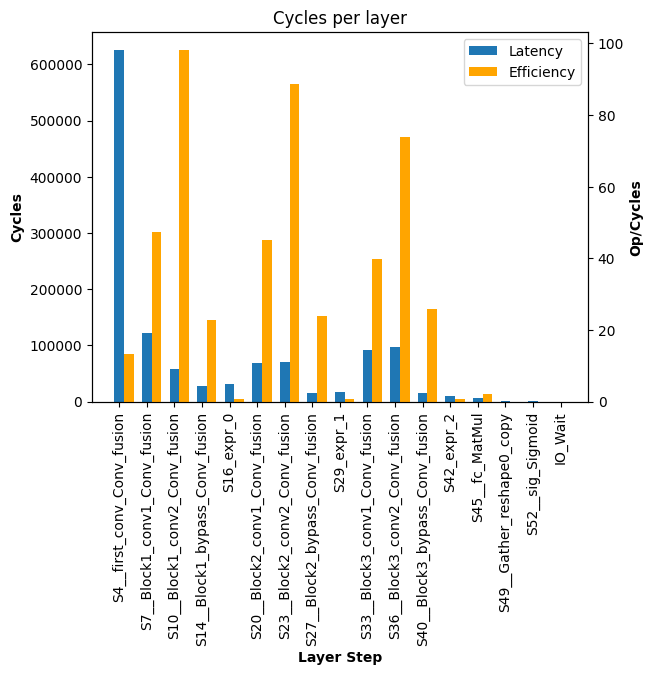

In [36]:
res.plot_performance();

No content found in the memory for this area L3


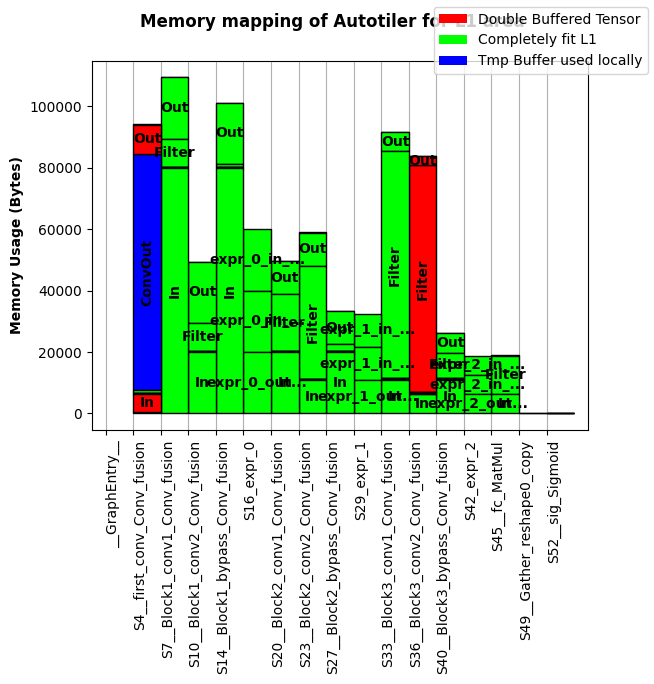

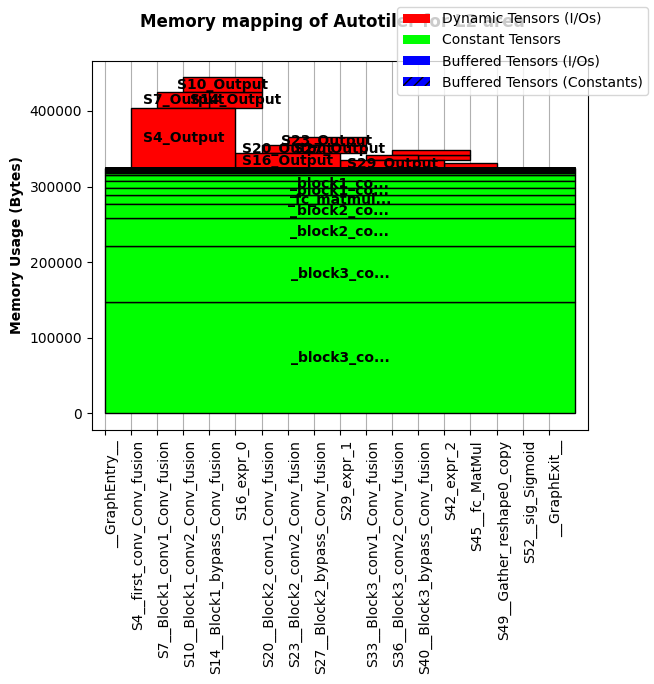

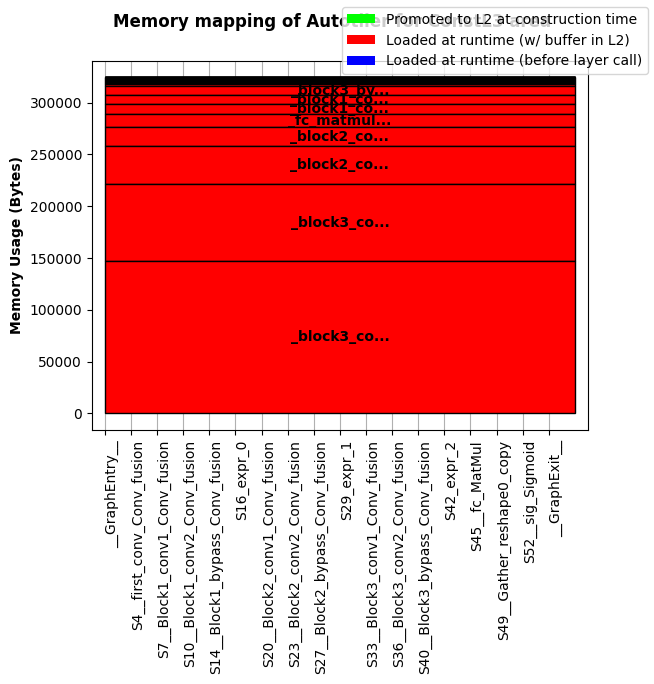

In [37]:
fig = res.plot_memory_boxes()

In [38]:
out_gap_steer = np.fromfile(directory + "/Output_1.bin", np.int8)   # steer: int8 (can be negative)
out_gap_coll  = np.fromfile(directory + "/Output_2.bin", np.uint8)  # coll: uint8 (sigmoid -> 0..255)
in_gap = np.fromfile(directory + "/Input_1.bin", np.uint8)

print(f"Inputs from Target:\n{in_gap}")
print(f"\nOutputs from Target:")
print(f"Steer (int8):      {out_gap_steer}")
print(f"Collision (uint8): {out_gap_coll}")

Inputs from Target:
[126 126 141 ... 116 116 115]

Outputs from Target:
Steer (int8):      [-128]
Collision (uint8): [128]


In [39]:
out_idxs = get_output_idxs(G)

print(f"Inputs from NNTool:\n{qout[0][0].flatten()}")
print(f"\nOutputs from NNTool:")
print(f"Steer (int8):      {qout[out_idxs[0]][0]}")
print(f"Collision (uint8): {qout[out_idxs[1]][0]}")

Inputs from NNTool:
[126 126 141 ... 116 116 115]

Outputs from NNTool:
Steer (int8):      [128]
Collision (uint8): [128]
